<a href="https://colab.research.google.com/github/aliabusohiban/Diabetes-Prediction-End-to-End-Machine-Learning-Pipeline/blob/main/Belt_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Diabetes Prediction — Machine Learning Project
**Course:** Intro to ML — Version B  
**Dataset:** Pima Indians Diabetes (extended with demographic features)  
**Goal:** Build and compare classification models to predict whether a patient has diabetes.

---


## 1. Imports & Setup

Import all necessary libraries for data processing, visualization, and machine learning.

In [ ]:
# ── Core libraries ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn preprocessing & utilities ─────────────────────────────────────────
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# ── Classifiers ───────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay,
                             precision_recall_curve, f1_score)

set_config(transform_output='pandas')
print('✅ All imports successful.')

✅ All imports successful.


## 2. Helper Functions

These reusable functions handle model evaluation throughout the notebook.
`evaluate_classification` fits and scores a model on both train and test sets, printing
a full classification report and side-by-side confusion matrices so we can spot overfitting
at a glance.

In [ ]:
def classification_metrics(y_true, y_pred, label='',
                            output_dict=False, figsize=(10, 4),
                            normalize='true', cmap='Blues', colorbar=False):
    """Print a classification report and plot raw + normalised confusion matrices."""
    report = classification_report(y_true, y_pred)
    header = "-" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize=None, cmap='gist_gray',
        colorbar=colorbar, ax=axes[0])
    axes[0].set_title('Raw Counts')

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize=normalize, cmap=cmap,
        colorbar=colorbar, ax=axes[1])
    axes[1].set_title('Normalised Confusion Matrix')
    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                             figsize=(10, 4), normalize='true',
                             output_dict=False,
                             cmap_train='Blues', cmap_test='Reds',
                             colorbar=False):
    """Evaluate a fitted pipeline on both the training and test sets."""
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(
        y_train, y_train_pred, output_dict=True,
        figsize=figsize, colorbar=colorbar,
        cmap=cmap_train, label='Training Data')
    print()
    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(
        y_test, y_test_pred, output_dict=True,
        figsize=figsize, colorbar=colorbar,
        cmap=cmap_test, label='Test Data')

    if output_dict:
        return {'train': results_train, 'test': results_test}


def show_best_params(grid):
    """Pretty-print the winning hyperparameters from a GridSearchCV object."""
    print(f"Best recall_macro (CV): {grid.best_score_:.4f}")
    print("Best hyperparameters:")
    for k, v in grid.best_params_.items():
        print(f"  {k}: {v}")

print('✅ Helper functions defined.')

def plot_roc_curve(model, X_test, y_test, model_name='Model', ax=None):
    """Plot ROC curve with AUC score for a fitted pipeline."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name)
    ax.plot([0, 1], [0, 1], ls='--', color='grey', label='Baseline (AUC = 0.5)')
    ax.set_title(f'ROC Curve — {model_name}')
    ax.legend(loc='lower right')
    plt.tight_layout()
    return ax


def plot_lr_coefficients(pipeline, feature_names_out, title='LR Coefficients'):
    """Plot Logistic Regression coefficients as a horizontal bar chart.

    For tree-based models, use feature_importances_ instead.
    This function is specific to linear models (Logistic Regression).
    """
    lr_step = pipeline.named_steps.get(
        'logisticregression',
        pipeline[-1]  # fallback: last step
    )
    coefs = lr_step.coef_[0]
    coef_df = pd.DataFrame({
        'Feature': feature_names_out,
        'Coefficient': coefs
    }).sort_values('Coefficient', key=abs, ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
    ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Coefficient value (positive = ↑ diabetes risk)')
    plt.tight_layout()
    plt.show()
    return coef_df


def threshold_analysis(model, X_test, y_test, thresholds=None):
    """Compare precision, recall, F1, and accuracy across decision thresholds.

    LR default threshold is 0.5, but for imbalanced medical data a lower
    threshold (0.35–0.40) often catches more diabetic patients.
    """
    if thresholds is None:
        thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
    proba = model.predict_proba(X_test)[:, 1]
    records = []
    for t in thresholds:
        y_pred_t = (proba >= t).astype(int)
        rep = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
        records.append({
            'Threshold': t,
            'Recall (diabetic)':   round(rep['1']['recall'],    3),
            'Precision (diabetic)':round(rep['1']['precision'], 3),
            'F1 (diabetic)':       round(rep['1']['f1-score'],  3),
            'Recall (macro)':      round(rep['macro avg']['recall'], 3),
            'Accuracy':            round(rep['accuracy'], 3),
        })
    df_thresh = pd.DataFrame(records)
    print(df_thresh.to_string(index=False))
    return df_thresh


print('✅ Enhanced helper functions defined.')


✅ Helper functions defined.
✅ Enhanced helper functions defined.


## 3. Load Data

Load the dataset from Google Drive. After loading, we take a first look at the shape,
column names, and sample rows to orient ourselves before cleaning.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week08/Data/Belt2_B_diabetes_v2_final.csv'
df = pd.read_csv(fpath)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (642, 10)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
0,4,189.0,110.0,31.0,NaN,0_68,overweight,18 - 44,F,0
1,2,157.0,74.0,35.0,440.0,0.134,obese_2,18 - 44,F,0
2,6,98.0,58.0,33.0,190.0,0.43,obese_1,18 - 44,F,0
3,6,111.0,64.0,39.0,NaN,0.26,obese_1,18 - 44,F,0
4,3,106.0,72.0,NaN,NaN,0_207,overweight,18 - 44,F,0
5,7,125.0,86.0,NaN,NaN,0.304,obese_2,45 - 64,F,0
6,1,106.0,76.0,NaN,NaN,0.19699999999999998,obese_2,18 - 44,F,0
7,6,105.0,80.0,28.0,NaN,0.878,obese_1,18 - 44,F,0
8,7,159.0,64.0,NaN,NaN,0.294,overweight,18 - 44,F,0
9,7,81.0,78.0,40.0,48.0,0_261,obsese_3,18 - 44,F,0


## 4. Data Cleaning

### 4.1 Inspect Data Types & Missing Values

First, we inspect each column's data type and count of non-null values.
This gives us a map of what needs fixing before analysis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               642 non-null    int64  
 1   Glucose                   638 non-null    float64
 2   BloodPressure             616 non-null    float64
 3   SkinThickness             455 non-null    float64
 4   Insulin                   331 non-null    float64
 5   DiabetesPedigreeFunction  642 non-null    object 
 6   WeightGroup               642 non-null    object 
 7   AgeGroup                  642 non-null    object 
 8   Gender                    642 non-null    object 
 9   Outcome                   642 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 50.3+ KB


We have 642 rows and 10 columns.


*   4 categorical columns.
*   7 numerical columns.


### 4.2 Fix Data Types

`DiabetesPedigreeFunction` is stored as `object` (string) but must be `float64`
according to the data dictionary. We cast it explicitly.

In [ ]:
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].astype(float)
print("✅ DiabetesPedigreeFunction dtype:", df['DiabetesPedigreeFunction'].dtype)

✅ DiabetesPedigreeFunction dtype: float64


### 4.3 Inspect & Fix Categorical Columns

We check every string column for inconsistent or unexpected values
(typos, wrong casing, sentinel strings like `'MISSING'`) before treating them as real nulls.

In [ ]:
string_cols = df.select_dtypes('object').columns
for col in string_cols:
    print(f"\n── Value Counts: {col} ──")
    print(df[col].value_counts(dropna=False))


── Value Counts: WeightGroup ──
WeightGroup
obese_1           196
overweight        146
obese_2           126
obsese_3           87
healthy weight     75
MISSING             8
underweight         4
Name: count, dtype: int64

── Value Counts: AgeGroup ──
AgeGroup
18 - 44    528
45 - 64    103
>65          8
<65          3
Name: count, dtype: int64

── Value Counts: Gender ──
Gender
F    565
M     60
m     17
Name: count, dtype: int64


**Findings:**
- `Gender` contains `'m'` which should be `'M'` (capitalisation typo).
- `AgeGroup` contains `'<65'` which is not a valid age group — converted to `NaN`.
- `WeightGroup` contains `'MISSING'` as a sentinel string — converted to `NaN`.

Each issue is fixed below without dropping any rows or columns.

In [ ]:
# Fix Gender capitalisation typo
df['Gender'] = df['Gender'].replace('m', 'M')

# Convert invalid AgeGroup value to NaN
df.loc[df['AgeGroup'] == '<65', 'AgeGroup'] = np.nan

# Convert MISSING sentinel string to true NaN
df.loc[df['WeightGroup'] == 'MISSING', 'WeightGroup'] = np.nan

# Fix the typo mistake in WeightGroup feature
df['WeightGroup'] = df['WeightGroup'].replace('obsese_3', 'obese_3')

print("✅ Categorical columns cleaned.")
print("\nGender counts:     ", df['Gender'].value_counts().to_dict())
print("AgeGroup nulls:    ", df['AgeGroup'].isna().sum())
print("WeightGroup counts: ", df['WeightGroup'].value_counts().to_dict())

✅ Categorical columns cleaned.

Gender counts:      {'F': 565, 'M': 77}
AgeGroup nulls:     3
WeightGroup counts:  {'obese_1': 196, 'overweight': 146, 'obese_2': 126, 'obese_3': 87, 'healthy weight': 75, 'underweight': 4}


### 4.4 Inspect & Fix Numeric Columns

We use `.describe()` to look for impossible numeric values
(e.g., a pregnancy count of 1000).

In [ ]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Outcome
count,642.00,638.00,616.00,455.00,331.00,6.420000e+02,642.00
mean,5.45,124.04,72.40,29.48,159.00,2.131153e+14,0.42
std,39.46,30.76,12.31,10.53,117.26,2.336298e+15,0.49
min,0.00,56.00,24.00,7.00,14.00,8.000000e-02,0.00
25%,1.00,100.00,64.00,22.00,82.50,2.500000e-01,0.00
50%,3.00,121.00,72.00,30.00,130.00,4.000000e-01,0.00
75%,6.00,144.00,80.00,36.50,192.50,6.700000e-01,1.00
max,1000.00,199.00,114.00,99.00,846.00,3.470000e+16,1.00


`Pregnancies` has a maximum value of **1000**, which is biologically impossible.
This is clearly a data-entry error. We replace it with `NaN` so it can be
imputed properly alongside other missing numeric values.

In [ ]:
df.loc[df['Pregnancies'] == 1000, 'Pregnancies'] = np.nan
print("✅ Impossible Pregnancies value removed.")
print(df['Pregnancies'].describe().round(2))

✅ Impossible Pregnancies value removed.
count    641.00
mean       3.90
std        3.41
min        0.00
25%        1.00
50%        3.00
75%        6.00
max       15.00
Name: Pregnancies, dtype: float64


### 4.5 Missing Value Summary

After all corrections, we print a clean summary of missing values across all columns.
This table guides our imputation strategy in the modelling pipeline.

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_summary.to_string())

               Missing Count  Missing %
Insulin                  311      48.44
SkinThickness            187      29.13
BloodPressure             26       4.05
WeightGroup                8       1.25
Glucose                    4       0.62
AgeGroup                   3       0.47
Pregnancies                1       0.16


## 5. Exploratory Data Analysis (EDA)

### 5.1 Univariate EDA — Plotting Functions

Two helper functions visualise individual columns.
`explore_categorical` shows a count plot with null info.
`explore_numeric` shows a histogram + boxplot pair with mean/median lines.

In [ ]:
def explore_categorical(df, x, fillna=True, placeholder='MISSING',
                        figsize=(6, 4), order=None):
    """Count plot for a categorical column with null diagnostics."""
    temp_df = df.copy()
    null_count = temp_df[x].isna().sum()
    null_perc = null_count / len(temp_df) * 100
    if fillna:
        temp_df[x] = temp_df[x].fillna(placeholder)

    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=figsize)
    sns.countplot(data=temp_df, x=x, ax=ax, order=order, palette='viridis')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(f"Column: {x}", fontweight='bold')
    fig.tight_layout()
    plt.show()

    print(f"- NaN's Found: {null_count} ({round(null_perc, 2)}%)")
    print(f"- Unique Values: {temp_df[x].nunique()}")
    val_counts = temp_df[x].value_counts(dropna=False)
    most_common_val = val_counts.index[0]
    freq = val_counts.values[0]
    perc_most_common = freq / len(temp_df) * 100
    print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common, 2)}%)")
    if perc_most_common > 98:
        print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
    else:
        print("- Not constant or quasi-constant.")
    return fig, ax


def explore_numeric(df, x, figsize=(6, 5)):
    """Histogram + boxplot for a numeric column with null diagnostics."""
    null_count = df[x].isna().sum()
    null_perc = null_count / len(df) * 100

    gridspec = {'height_ratios': [0.7, 0.3]}
    fig, axes = plt.subplots(nrows=2, figsize=figsize, sharex=True, gridspec_kw=gridspec)

    sns.histplot(data=df, x=x, bins=30, color='#4cc9f0', edgecolor='white', ax=axes[0])
    mean_val = df[x].mean()
    med_val = df[x].median()
    axes[0].axvline(mean_val, color='red', ls='--', label=f"Mean = {mean_val:,.2f}")
    axes[0].axvline(med_val, color='yellow', ls='--', label=f"Median = {med_val:,.2f}")
    axes[0].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.3)
    axes[1].grid(axis='x', linestyle='--', alpha=0.3)

    sns.boxplot(data=df, x=x, ax=axes[1], color='#4cc9f0')
    axes[0].set_title(f"Column: {x}", fontweight='bold')
    fig.tight_layout()
    plt.show()

    print(f"- NaN's Found: {null_count} ({round(null_perc, 2)}%)")
    print(f"- Unique Values: {df[x].nunique()}")
    val_counts = df[x].value_counts(dropna=False)
    most_common_val = val_counts.index[0]
    freq = val_counts.values[0]
    perc_most_common = freq / len(df) * 100
    print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common, 2)}%)")
    if perc_most_common > 98:
        print(f"\n- [!] Warning: '{x}' is quasi-constant and should be dropped.")
    else:
        print("- Not constant or quasi-constant.")
    return fig, axes

print('✅ EDA plotting functions defined.')

✅ EDA plotting functions defined.


### 5.2 Categorical Features — Univariate

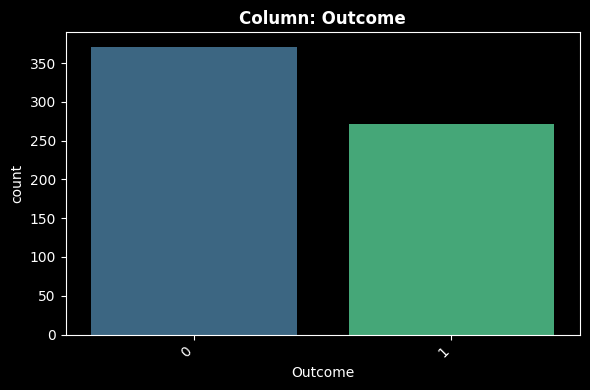

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: '0' occurs 371 times (57.79%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'Outcome');

**Outcome** shows a class imbalance: roughly 42% of patients have diabetes (Outcome = 1)
vs 58% without. This imbalance should be addressed during modelling, for example,
by using `class_weight='balanced'` or evaluating with macro-recall rather than accuracy alone.

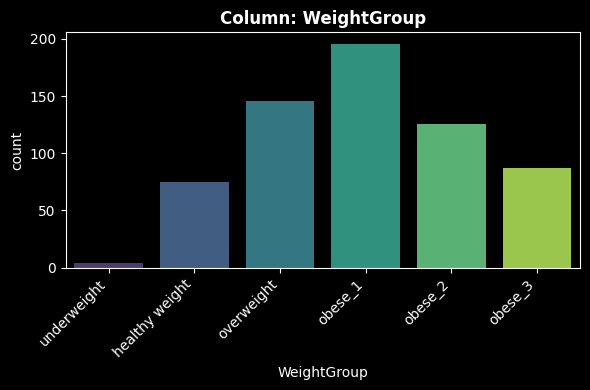

- NaN's Found: 8 (1.25%)
- Unique Values: 7
- Most common value: 'obese_1' occurs 196 times (30.53%)
- Not constant or quasi-constant.


In [ ]:
ord_W = ['underweight', 'healthy weight', 'overweight', 'obese_1', 'obese_2', 'obese_3']
explore_categorical(df, 'WeightGroup', order=ord_W);

**WeightGroup** has 8 nulls, we see the peaple wiht obisity has the highest rate of diabetas.

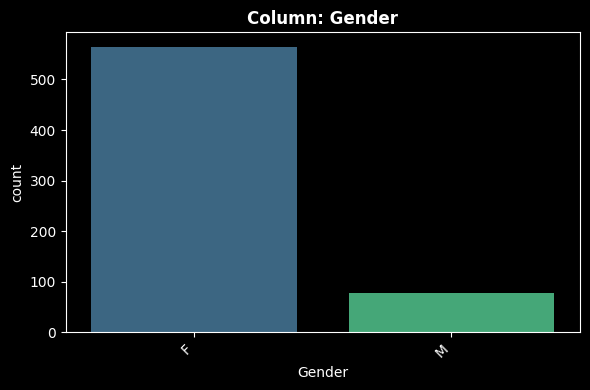

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'F' occurs 565 times (88.01%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'Gender');

**Gender** has un balanced data, 88% is females.

### 5.3 Numeric Features — Univariate

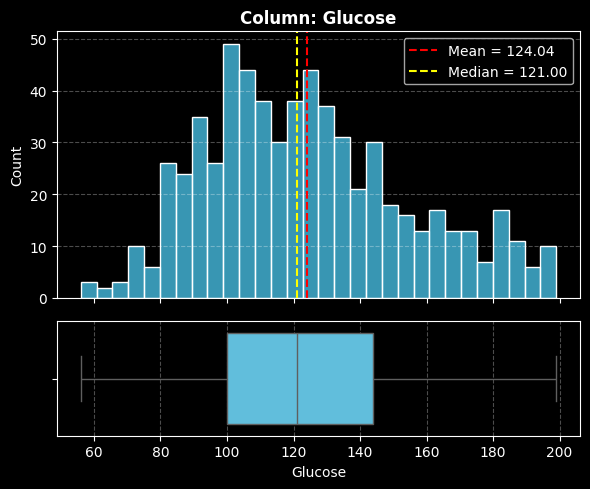

- NaN's Found: 4 (0.62%)
- Unique Values: 131
- Most common value: '99.0' occurs 15 times (2.34%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'Glucose');

**Glucose** is roughly bell-shaped with a slight right skew. The mean (≈124 mg/dL)
is close to the median. Glucose is likely to be one of the
strongest predictors of diabetes, elevated blood sugar is a defining diagnostic criterion.

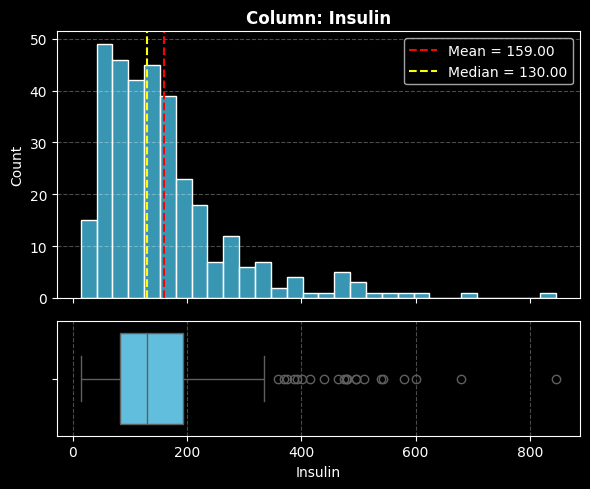

- NaN's Found: 311 (48.44%)
- Unique Values: 175
- Most common value: 'nan' occurs 311 times (48.44%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'Insulin');

**Insulin** is heavily right-skewed with a large number of zeros and extreme high values
(visible as outliers in the boxplot). It also has the highest missing rate (~48.5%) among numeric columns.
KNN imputation is more appropriate than simple mean/median imputation here given the strong
correlations Insulin has with Glucose.

### 5.4 Correlation Heatmap

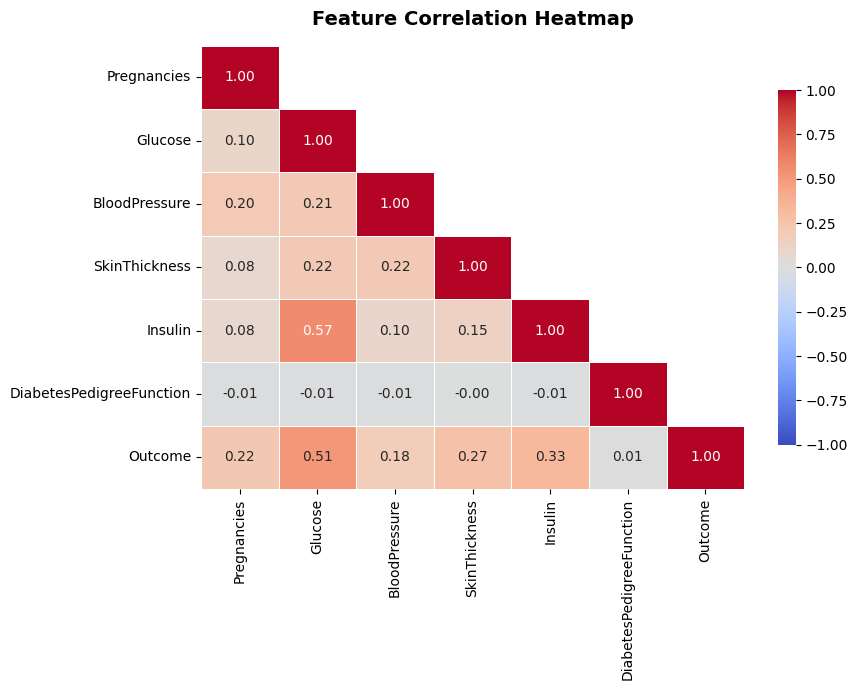

In [ ]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True,
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Correlation Heatmap** reveals that **Glucose** has the strongest positive correlation
with Outcome (≈0.51), confirming its importance as a predictor. **Insulin** and **Pregnancies** are
moderately correlated with each other (expected) and both show mild positive correlation with Outcome.
**BloodPressure** and **SkinThickness** have weak correlations with the target, suggesting they may
contribute less predictive power individually.

### 5.5 Multivariate EDA — Categorical vs Outcome

The functions below plot each categorical feature against the target in two panels:
a count plot showing class distribution, and a bar plot showing the diabetes rate per category.

In [ ]:
def plot_outcome_vs_categorical(df, col, target='Outcome',
                               fillna=True, placeholder='MISSING',order=False,
                               figsize=(12, 5), palette='Set2'):
    """Side-by-side count plot and diabetes-rate bar chart for a categorical feature."""
    temp_df = df.copy()
    if fillna:
        temp_df[col] = temp_df[col].fillna(placeholder)
    else:
        temp_df = temp_df.dropna(subset=[col])

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    sns.countplot(data=temp_df, x=col, hue=target, ax=axes[0], palette=palette, order=order)
    axes[0].set_title(f"{col} — Count by Outcome")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title='Diabetes', labels=['No', 'Yes'])

    rate_df = temp_df.groupby(col)[target].mean().reset_index()
    rate_df.columns = [col, 'Diabetes Rate']
    sns.barplot(data=rate_df, x=col, y='Diabetes Rate', ax=axes[1],
                palette=palette, edgecolor='black', order=order)
    axes[1].set_title(f"{col} — Diabetes Rate")
    axes[1].set_ylabel("Probability of Diabetes")
    axes[1].set_ylim(0, 1)
    axes[1].axhline(temp_df[target].mean(), ls='--', color='red', label='Overall avg')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    return fig, axes

print('✅ Multivariate plotting function defined.')

✅ Multivariate plotting function defined.


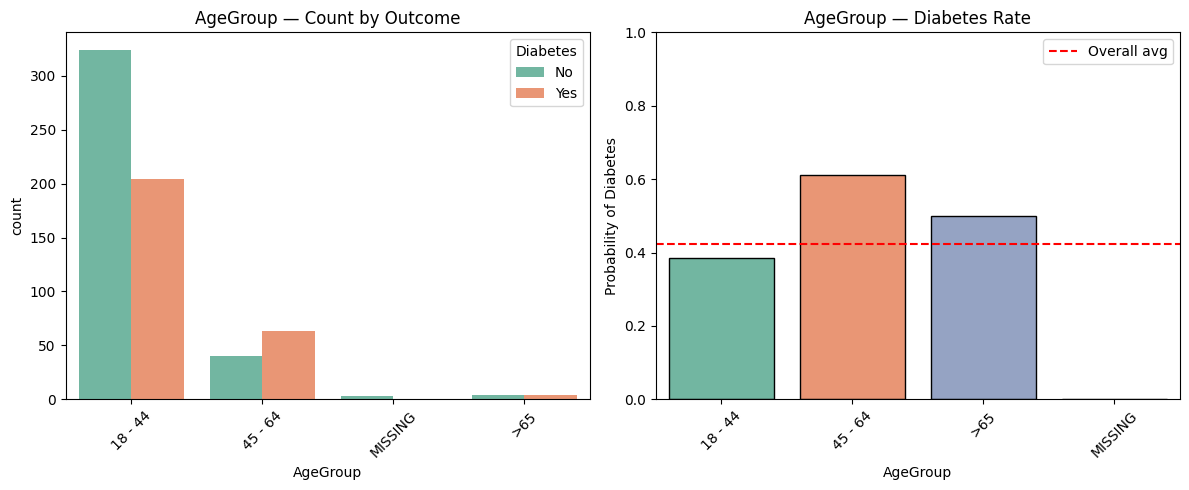

In [ ]:
plot_outcome_vs_categorical(df, 'AgeGroup');

**AgeGroup vs Outcome:** Diabetes rates increase clearly with age — patients aged **>65**
have a diabetes rate nearly double that of the 18–44 group. The `MISSING` category
(imputed placeholder) sits close to the overall average, suggesting missing age values
are roughly random rather than systematically biased. This confirms AgeGroup is a
meaningful ordinal predictor.

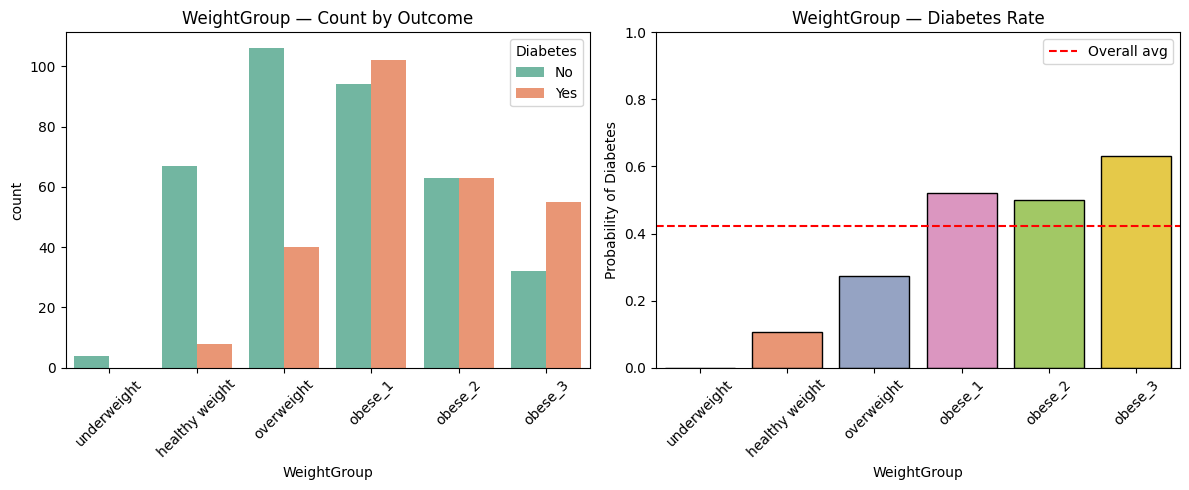

In [ ]:
ord_W= ['underweight', 'healthy weight', 'overweight', 'obese_1', 'obese_2', 'obese_3']

plot_outcome_vs_categorical(df, 'WeightGroup', fillna=True, order=ord_W);

**WeightGroup vs Outcome:** There is a clear positive trend — heavier weight categories
(obese_1 through obese_3) show substantially higher diabetes rates compared to underweight
and healthy weight groups. This is expected clinically and confirms WeightGroup carries
strong predictive signal. The ordinal encoding (underweight → obese_3) is justified
because the diabetes risk increases with weight class.

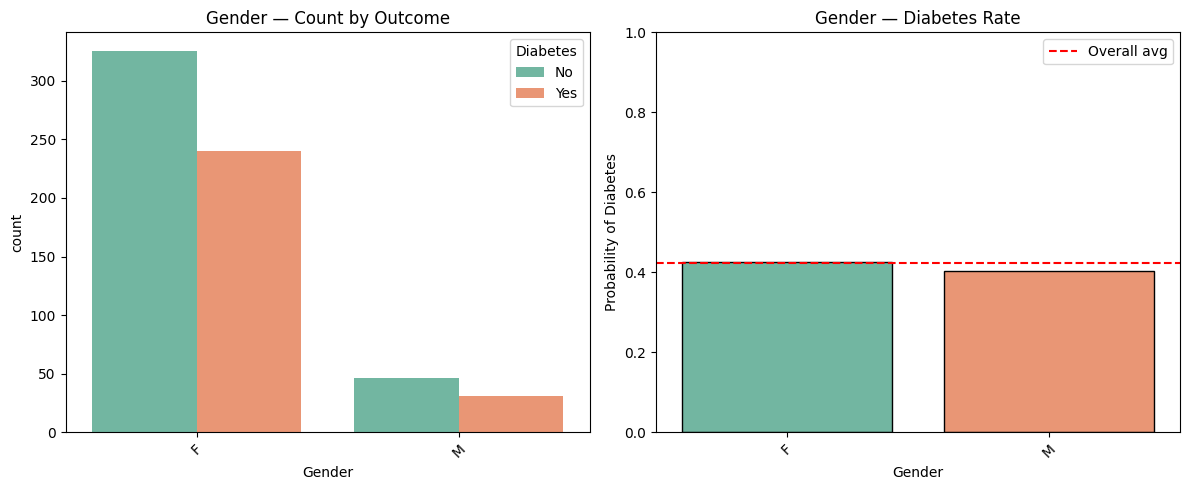

In [ ]:
plot_outcome_vs_categorical(df, 'Gender');

**Gender vs Outcome:** The diabetes rate is similar for Male and Female patients in this dataset.
Gender does not appear to be a strong standalone predictor of diabetes.

### 5.6 Multivariate EDA — Numeric vs Outcome

In [ ]:
def plot_outcome_vs_numeric(df, col, target='Outcome', figsize=(12, 5)):
    """Boxplot and overlapping KDE to compare a numeric feature's distribution by outcome."""
    temp_df = df.dropna(subset=[col]).copy()

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    sns.boxplot(data=temp_df, x=target, y=col, ax=axes[0],
                palette={'0': '#4cc9f0', '1': '#f72585'})
    axes[0].set_title(f"{col} vs Outcome — Boxplot")
    axes[0].set_xticklabels(['No Diabetes', 'Diabetes'])

    sns.kdeplot(data=temp_df, x=col, hue=target, ax=axes[1], fill=True,
                palette={0: '#4cc9f0', 1: '#f72585'}, alpha=0.5)
    axes[1].set_title(f"{col} — Distribution by Outcome")
    axes[1].legend(title='Diabetes', labels=['Yes', 'No'])

    plt.tight_layout()
    return fig, axes

print('✅ Numeric multivariate plot function defined.')

✅ Numeric multivariate plot function defined.


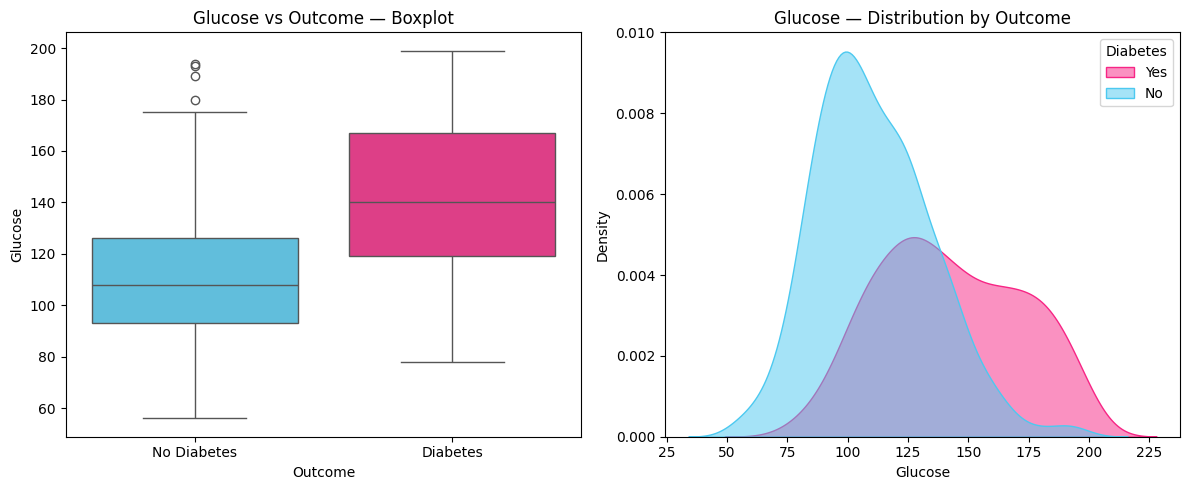

In [ ]:
plot_outcome_vs_numeric(df, 'Glucose');

**Glucose vs Outcome:** This is the clearest separation in the dataset. Diabetic patients
(purple) show a distribution shifted significantly to the right — higher glucose levels —
with very little overlap below ~100 mg/dL. This confirms Glucose as the single most
discriminative feature for predicting diabetes.

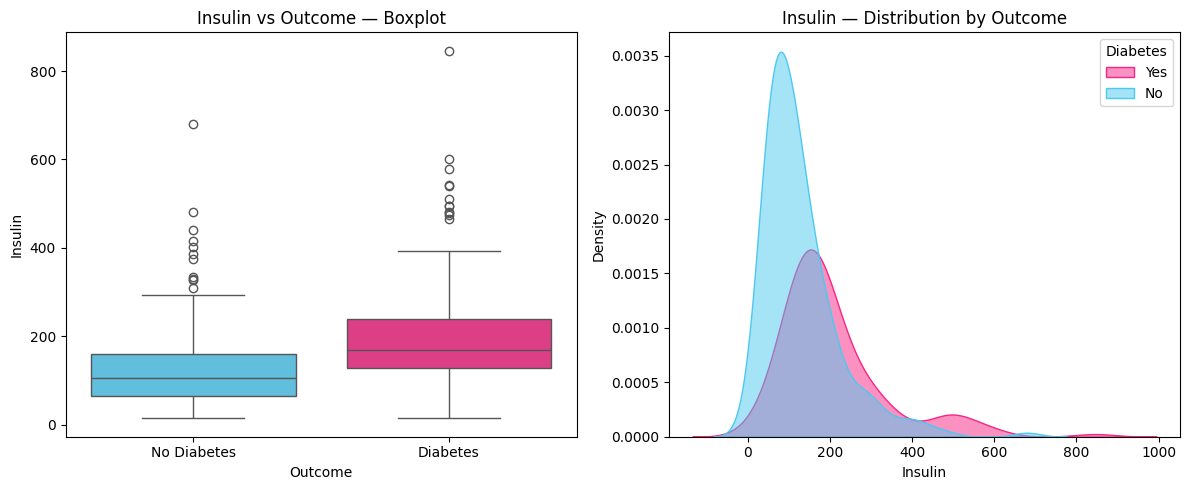

In [ ]:
plot_outcome_vs_numeric(df, 'Insulin');

**Insulin vs Outcome:** Diabetic patients tend to have higher insulin levels, but the
distributions overlap heavily and the variable is right-skewed with many outliers.
The high missing rate (~48%) also limits its reliability. Despite this, it is retained
as it still carries some signal — especially in combination with Glucose.

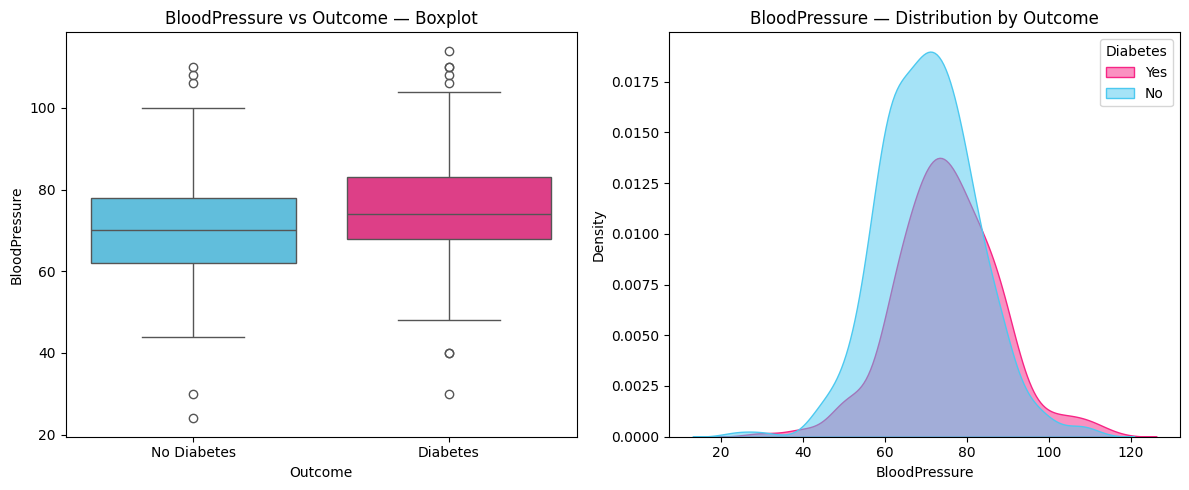

In [ ]:
plot_outcome_vs_numeric(df, 'BloodPressure');

**BloodPressure vs Outcome:** The two distributions are nearly identical, with
only a slight elevation in the diabetic group. Blood pressure alone is a weak predictor
of diabetes in this dataset, which aligns with its near-zero correlation with Outcome
seen in the heatmap.

## 6. Train / Test Split

We split the data **before** any imputation or encoding to prevent data leakage.
`stratify=y` ensures that the proportion of diabetic patients is preserved in both sets.

In [ ]:
TARGET = 'Outcome'
X = df.drop(columns=TARGET)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train shape : {X_train.shape}")
print(f"Test  shape : {X_test.shape}")
print(f"Train diabetes rate : {y_train.mean():.3f}")
print(f"Test  diabetes rate : {y_test.mean():.3f}")

Train shape : (481, 9)
Test  shape : (161, 9)
Train diabetes rate : 0.422
Test  diabetes rate : 0.422


## 7. Preprocessing Pipeline

### Justification of Encoding Strategy

| Column type | Encoder | Reason |
|---|---|---|
| `AgeGroup`, `WeightGroup` | **OrdinalEncoder** | These have a natural, meaningful order (e.g., healthy weight < overweight < obese). Using ordinal encoding preserves this order so tree-based models can make better splits. |
| `Gender` | **OneHotEncoder** | No natural order between Male/Female. OHE creates a binary indicator without imposing an arbitrary ranking. |
| Numeric cols | **KNNImputer → StandardScaler** | KNN imputation uses the most similar patients (by all features) to fill missing values — better than a global mean for skewed distributions like Insulin. Scaling is required by distance-based models (KNN, Logistic Regression). |

All transformations are fit **only on training data** and applied to the test set
to avoid data leakage.

In [ ]:
# ── Define column groups ────────────────────────────────────────────────────────
ORD_COLS = ['AgeGroup', 'WeightGroup']
OHE_COLS = (
    X_train.select_dtypes('object')
    .drop(columns=ORD_COLS)
    .columns.tolist()
)
NUM_COLS = X_train.select_dtypes('number').columns.tolist()

print("Ordinal columns :", ORD_COLS)
print("OHE columns     :", OHE_COLS)
print("Numeric columns :", NUM_COLS)

Ordinal columns : ['AgeGroup', 'WeightGroup']
OHE columns     : ['Gender']
Numeric columns : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction']


In [ ]:
# ── Ordinal sub-pipeline ────────────────────────────────────────────────────────
# Categories must be listed in ascending order for OrdinalEncoder to assign
# meaningful integer codes (0 = lowest, n = highest).
ORDINAL_ORDERS = [
    ['18 - 44', '45 - 64', '>65'],                                                       # AgeGroup
    ['underweight', 'healthy weight', 'overweight', 'obese_1', 'obese_2', 'obese_3'],   # WeightGroup
]

ord_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),   # fill nulls with the most common category
    OrdinalEncoder(categories=ORDINAL_ORDERS,
                   handle_unknown='use_encoded_value', unknown_value=-1),
    StandardScaler(),
)

# ── Nominal sub-pipeline ────────────────────────────────────────────────────────
ohe_pipe = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='MISSING'),
    OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
)

# ── Numeric sub-pipeline ────────────────────────────────────────────────────────
# KNNImputer uses the k=5 nearest neighbours (by Euclidean distance across all
# non-missing features) to estimate missing values — more accurate than mean/median
# for skewed, correlated features like Insulin and SkinThickness.
num_pipe = make_pipeline(
    KNNImputer(n_neighbors=5),
    StandardScaler(),
)

# ── Assemble full preprocessor ─────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',     num_pipe, NUM_COLS),
        ('ordinal',     ord_pipe, ORD_COLS),
        ('categorical', ohe_pipe, OHE_COLS),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)
print('✅ Preprocessing pipeline assembled.')

✅ Preprocessing pipeline assembled.


## 8. Model Training & Evaluation

### Why `recall_macro` as the scoring metric?
In a medical screening context, **false negatives** (predicting no diabetes when the patient
actually has it) are more costly than false positives. We therefore optimise for
**recall (sensitivity)** across both classes. Using *macro* averaging weights each class
equally, which also counteracts the class imbalance (≈65/35 split).

### Why tuning sometimes makes results look worse
This is normal and can happen for this main reason:
* **Small dataset (n=642):** With only 481 training rows, hyperparameter searches can
   overfit to cross-validation folds, finding settings that work on specific folds but
   don't generalise.


### 8.1 Model 1: Decision Tree

A Decision Tree makes sequential binary splits on features to separate classes.
It is interpretable but prone to overfitting on training data. The default tree
(no depth limit) often memorises training data.

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       278
           1       1.00      1.00      1.00       203

    accuracy                           1.00       481
   macro avg       1.00      1.00      1.00       481
weighted avg       1.00      1.00      1.00       481



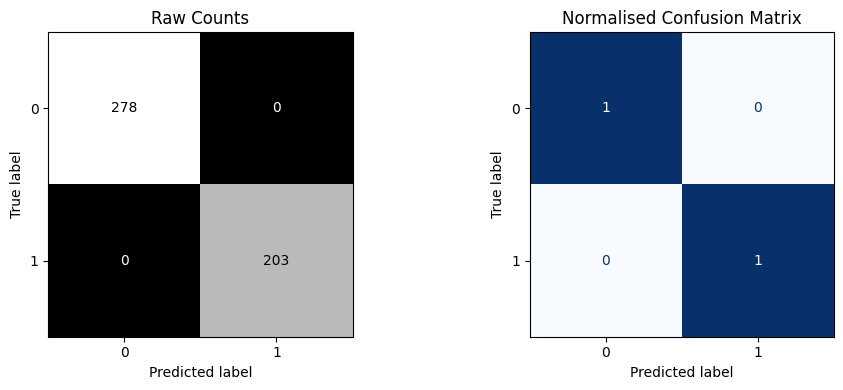


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.70      0.74      0.72        93
           1       0.61      0.56      0.58        68

    accuracy                           0.66       161
   macro avg       0.65      0.65      0.65       161
weighted avg       0.66      0.66      0.66       161



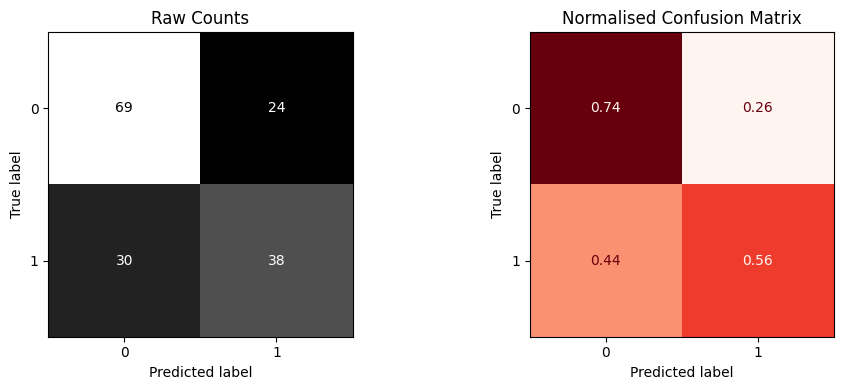

In [ ]:
# ── Default Decision Tree ──────────────────────────────────────────────────────
tree_default = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=42))
tree_default.fit(X_train, y_train)
evaluate_classification(tree_default, X_train, y_train, X_test, y_test)

Notice the near-perfect training scores vs. weaker test scores — a classic sign of
**overfitting**. The default tree grows until every leaf is pure, memorising noise in
the training data. Hyperparameter tuning (pruning) should reduce this gap.

Best recall_macro (CV): 0.7317
Best hyperparameters:
  decisiontreeclassifier__class_weight: balanced
  decisiontreeclassifier__max_depth: 7
  decisiontreeclassifier__min_samples_leaf: 20

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.71      0.78       278
           1       0.68      0.86      0.76       203

    accuracy                           0.77       481
   macro avg       0.78      0.78      0.77       481
weighted avg       0.79      0.77      0.77       481



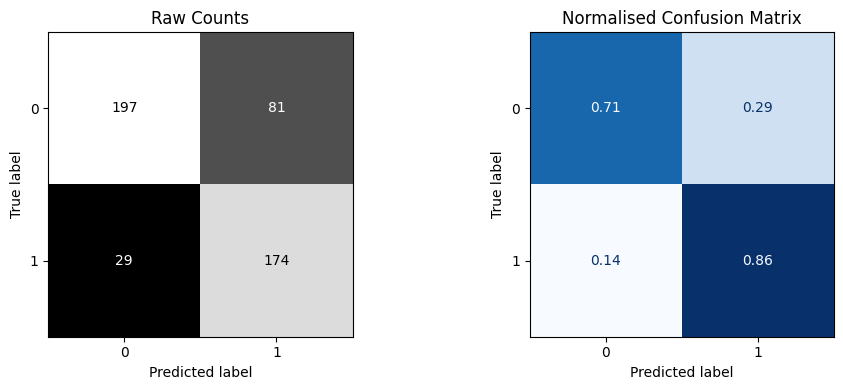


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.70      0.76        93
           1       0.66      0.81      0.73        68

    accuracy                           0.75       161
   macro avg       0.75      0.75      0.74       161
weighted avg       0.76      0.75      0.75       161



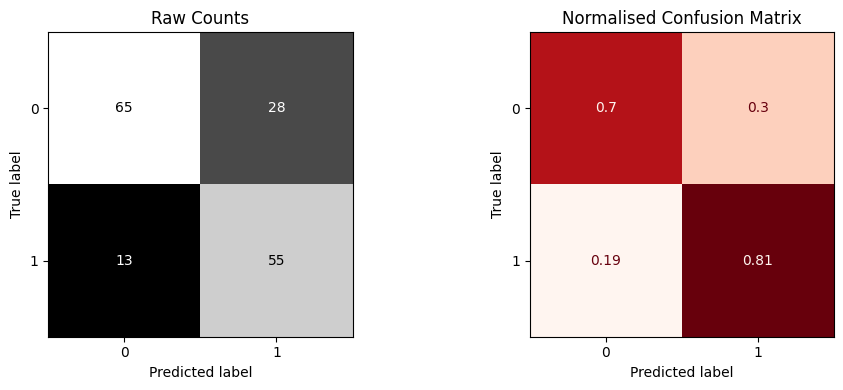

In [ ]:
# ── Tuned Decision Tree via GridSearchCV ────────────────────────────────────────
# max_depth prunes the tree; min_samples_leaf prevents splits on tiny groups;
# class_weight='balanced' up-weights the minority (diabetic) class.
dt_param_grid = {
    'decisiontreeclassifier__max_depth':        [3, 5, 7, 10, None],
    'decisiontreeclassifier__min_samples_leaf': [1, 5, 10, 20],
    'decisiontreeclassifier__class_weight':     ['balanced', None],
}

dt_grid = GridSearchCV(
    make_pipeline(preprocessor, DecisionTreeClassifier(random_state=42)),
    param_grid=dt_param_grid,
    scoring='recall_macro',
    cv=5,           # 5-fold CV is more stable than 3-fold on a small dataset
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)

show_best_params(dt_grid)
print()
evaluate_classification(dt_grid.best_estimator_, X_train, y_train, X_test, y_test)

### 8.2 Model 2: Logistic Regression

Logistic Regression is a linear model that estimates the probability of diabetes.
It works well on tabular data, is fast to train, and highly interpretable via its
coefficients. It requires scaled features (already handled in the pipeline).

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      0.83      0.80       278
           1       0.74      0.67      0.70       203

    accuracy                           0.76       481
   macro avg       0.76      0.75      0.75       481
weighted avg       0.76      0.76      0.76       481



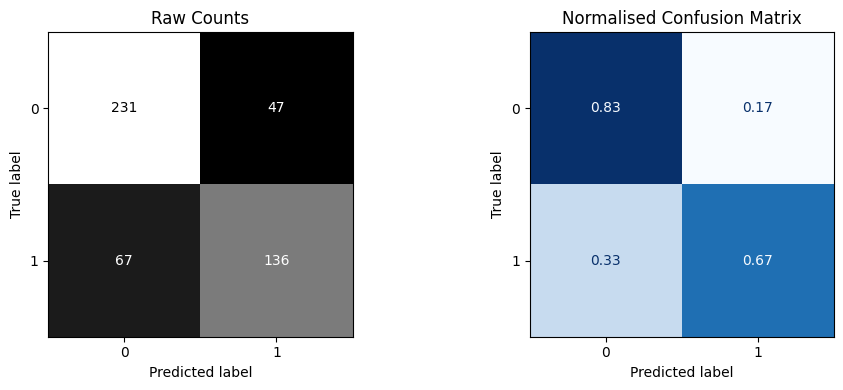


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        93
           1       0.68      0.57      0.62        68

    accuracy                           0.71       161
   macro avg       0.70      0.69      0.69       161
weighted avg       0.71      0.71      0.70       161



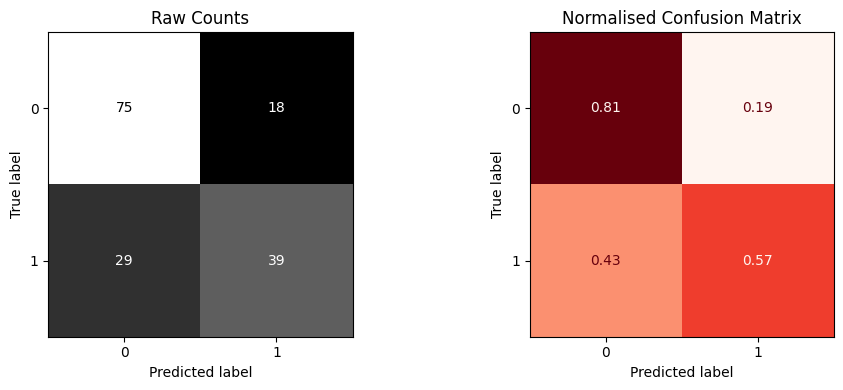

In [ ]:
# ── Default Logistic Regression ────────────────────────────────────────────────
lr_default = make_pipeline(
    preprocessor,
    LogisticRegression(random_state=42, max_iter=1000)
)
lr_default.fit(X_train, y_train)
evaluate_classification(lr_default, X_train, y_train, X_test, y_test)

In [ ]:
# ── Tuned Logistic Regression ───────────────────────────────────────────────────
# We use a list of dicts because not all solvers support all penalties.
# Using a single dict would test invalid combinations and raise errors.
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

lr_param_grid = [
    {   # lbfgs supports l2 and no penalty
        'logisticregression__solver':       ['lbfgs'],
        'logisticregression__penalty':      ['l2', None],
        'logisticregression__C':            C_values,
        'logisticregression__class_weight': ['balanced', None],
    },
    {   # liblinear supports l1 and l2
        'logisticregression__solver':       ['liblinear'],
        'logisticregression__penalty':      ['l1', 'l2'],
        'logisticregression__C':            C_values,
        'logisticregression__class_weight': ['balanced', None],
    },
    {   # saga supports l1, l2, elasticnet, and no penalty
        'logisticregression__solver':       ['saga'],
        'logisticregression__penalty':      ['l1', 'l2', None],
        'logisticregression__C':            C_values,
        'logisticregression__class_weight': ['balanced', None],
    },
    {   # elasticnet requires l1_ratio instead of C
        'logisticregression__solver':       ['saga'],
        'logisticregression__penalty':      ['elasticnet'],
        'logisticregression__l1_ratio':     [0.2, 0.5, 0.8],
        'logisticregression__class_weight': ['balanced', None],
    },
]

lr_grid = GridSearchCV(
    make_pipeline(preprocessor, LogisticRegression(random_state=42, max_iter=2000)),
    param_grid=lr_param_grid,
    scoring='recall_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

Fitting 5 folds for each of 118 candidates, totalling 590 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('knnimputer',
                                                                                          KNNImputer()),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['Pregnancies',
                                                                          'Glucose',
                                                                          'BloodPressure',
                                                                          'SkinThickness',
                                                                          'Insulin',
                                                                          'DiabetesPedigreeFunction']),
                                                                        ('ordinal',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strate...
                          'logisticregression__class_weight': ['balanced',
                                                               None],
                          'logisticregression__penalty': ['l1', 'l2', None],
                          'logisticregression__solver': ['saga']},
                         {'logisticregression__class_weight': ['balanced',
                                                               None],
                          'logisticregression__l1_ratio': [0.2, 0.5, 0.8],
                          'logisticregression__penalty': ['elasticnet'],
                          'logisticregression__solver': ['saga']}],
             scoring='recall_macro', verbose=1)

Best recall_macro (CV): 0.7487
Best hyperparameters:
  logisticregression__C: 0.1
  logisticregression__class_weight: balanced
  logisticregression__penalty: l2
  logisticregression__solver: lbfgs

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       278
           1       0.71      0.73      0.72       203

    accuracy                           0.76       481
   macro avg       0.76      0.76      0.76       481
weighted avg       0.76      0.76      0.76       481



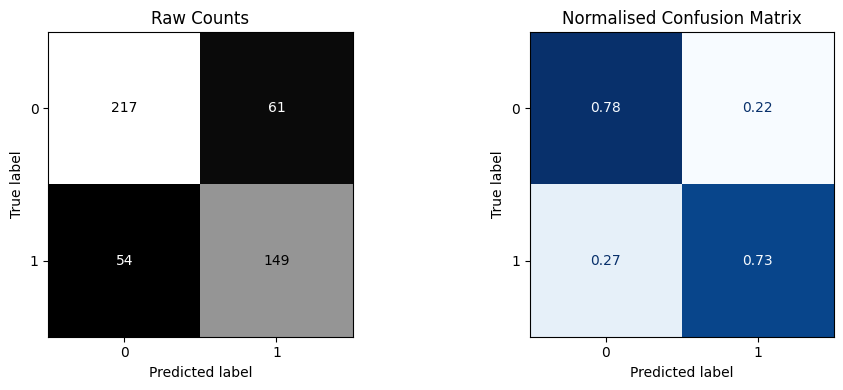


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        93
           1       0.66      0.66      0.66        68

    accuracy                           0.71       161
   macro avg       0.71      0.71      0.71       161
weighted avg       0.71      0.71      0.71       161



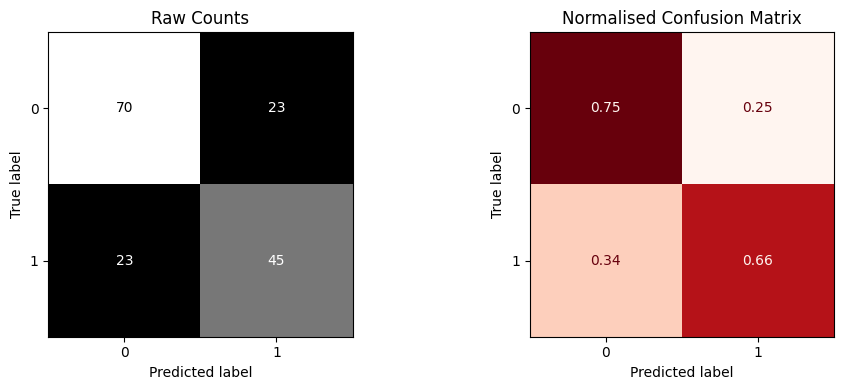

In [ ]:
show_best_params(lr_grid)
print()
evaluate_classification(lr_grid.best_estimator_, X_train, y_train, X_test, y_test)

### 8.3 Model 3: K-Nearest Neighbours

KNN classifies a new patient by finding the *k* most similar patients in the training set
and taking a majority vote. It is non-parametric (no assumptions about distribution)
but sensitive to irrelevant features and scale (scaling is handled in the pipeline).

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       278
           1       0.78      0.76      0.77       203

    accuracy                           0.81       481
   macro avg       0.80      0.80      0.80       481
weighted avg       0.81      0.81      0.81       481



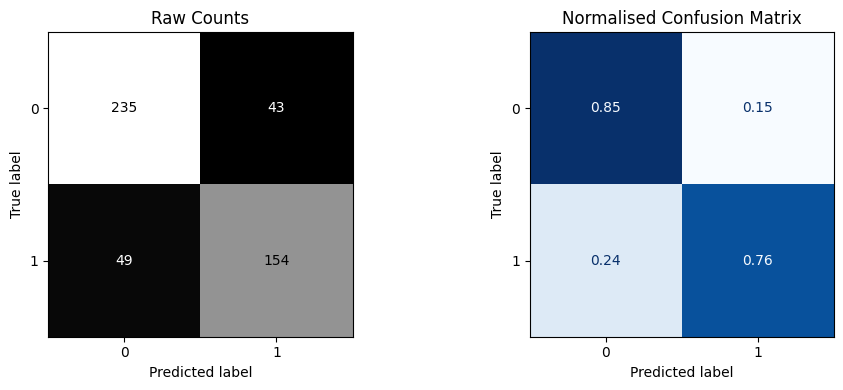


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.70      0.74      0.72        93
           1       0.62      0.57      0.60        68

    accuracy                           0.67       161
   macro avg       0.66      0.66      0.66       161
weighted avg       0.67      0.67      0.67       161



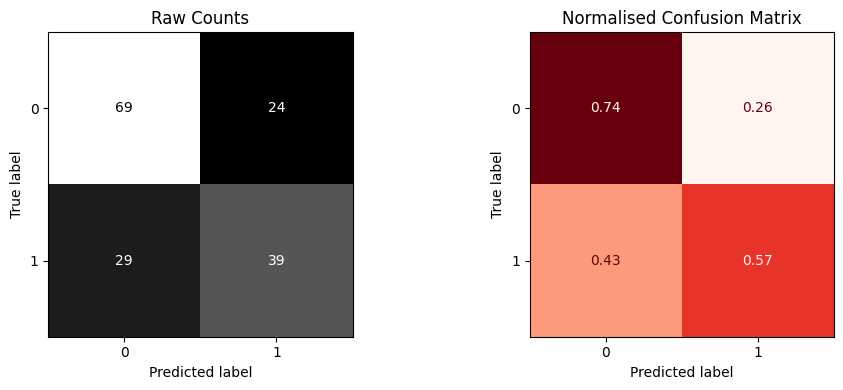

In [ ]:
# ── Default KNN ─────────────────────────────────────────────────────────────────
knn_default = make_pipeline(preprocessor, KNeighborsClassifier())
knn_default.fit(X_train, y_train)
evaluate_classification(knn_default, X_train, y_train, X_test, y_test)

In [ ]:
# ── Tuned KNN ───────────────────────────────────────────────────────────────────
# Odd k values avoid ties. We test Manhattan and Euclidean distances and
# both uniform and distance-based weighting.
knn_param_grid = [
    {   # Minkowski family: p=1 is Manhattan, p=2 is Euclidean
        'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
        'kneighborsclassifier__weights':     ['uniform', 'distance'],
        'kneighborsclassifier__metric':      ['minkowski'],
        'kneighborsclassifier__p':           [1, 2],
    },
    {   # Cosine similarity — useful when features have high correlation
        'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
        'kneighborsclassifier__weights':     ['uniform', 'distance'],
        'kneighborsclassifier__metric':      ['cosine'],
    },
]

knn_grid = GridSearchCV(
    make_pipeline(preprocessor, KNeighborsClassifier()),
    param_grid=knn_param_grid,
    scoring='recall_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)
knn_grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('knnimputer',
                                                                                          KNNImputer()),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['Pregnancies',
                                                                          'Glucose',
                                                                          'BloodPressure',
                                                                          'SkinThickness',
                                                                          'Insulin',
                                                                          'DiabetesPedigreeFunction']),
                                                                        ('ordinal',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strate...
             param_grid=[{'kneighborsclassifier__metric': ['minkowski'],
                          'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11,
                                                                15, 21, 31],
                          'kneighborsclassifier__p': [1, 2],
                          'kneighborsclassifier__weights': ['uniform',
                                                            'distance']},
                         {'kneighborsclassifier__metric': ['cosine'],
                          'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11,
                                                                15, 21, 31],
                          'kneighborsclassifier__weights': ['uniform',
                                                            'distance']}],
             scoring='recall_macro', verbose=1)

Best recall_macro (CV): 0.7470
Best hyperparameters:
  kneighborsclassifier__metric: cosine
  kneighborsclassifier__n_neighbors: 31
  kneighborsclassifier__weights: distance

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       278
           1       1.00      1.00      1.00       203

    accuracy                           1.00       481
   macro avg       1.00      1.00      1.00       481
weighted avg       1.00      1.00      1.00       481



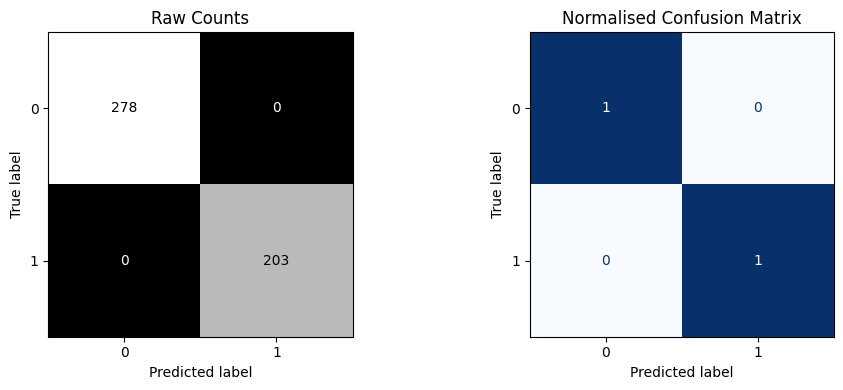


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        93
           1       0.63      0.59      0.61        68

    accuracy                           0.68       161
   macro avg       0.67      0.67      0.67       161
weighted avg       0.68      0.68      0.68       161



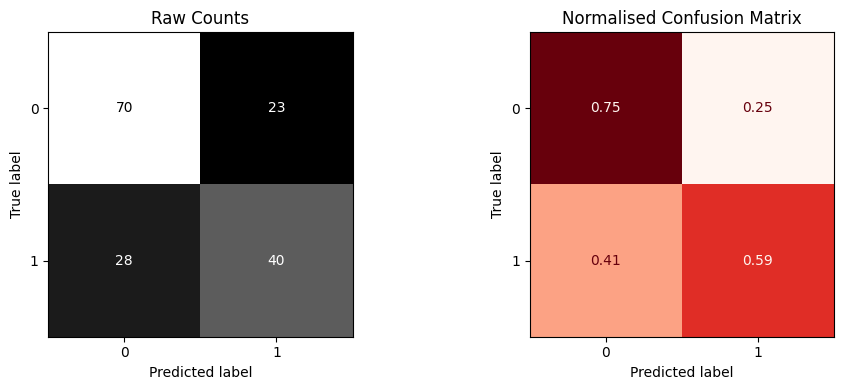

In [ ]:
show_best_params(knn_grid)
print()
evaluate_classification(knn_grid.best_estimator_, X_train, y_train, X_test, y_test)

### 8.4 Model 4: Random Forest

Random Forest builds an ensemble of decision trees on random subsets of the data
and features. It is more robust than a single tree (less overfitting) and handles
mixed data types, class imbalance, and non-linear relationships well.

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       278
           1       1.00      1.00      1.00       203

    accuracy                           1.00       481
   macro avg       1.00      1.00      1.00       481
weighted avg       1.00      1.00      1.00       481



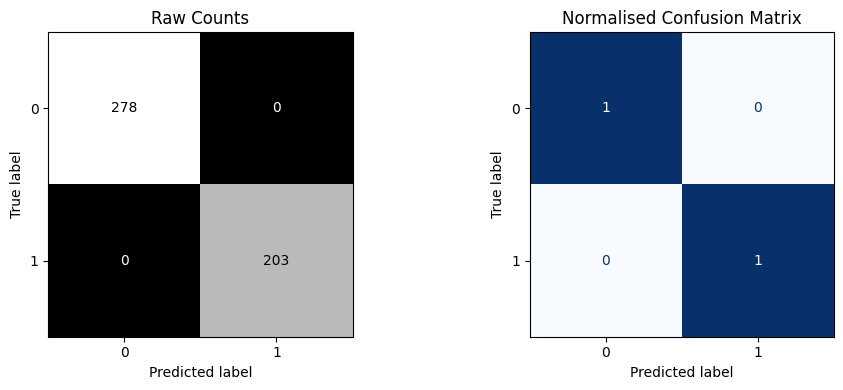


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.71      0.77      0.74        93
           1       0.64      0.56      0.60        68

    accuracy                           0.68       161
   macro avg       0.67      0.67      0.67       161
weighted avg       0.68      0.68      0.68       161



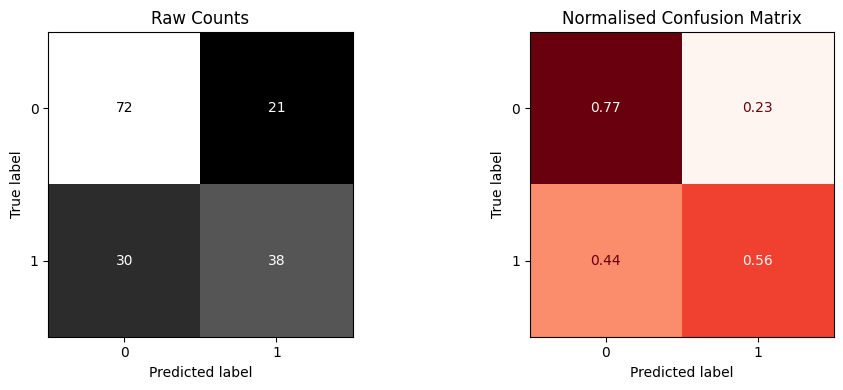

In [ ]:
# ── Default Random Forest ───────────────────────────────────────────────────────
rf_default = make_pipeline(preprocessor, RandomForestClassifier(random_state=42))
rf_default.fit(X_train, y_train)
evaluate_classification(rf_default, X_train, y_train, X_test, y_test)

In [ ]:
# ── Tuned Random Forest ─────────────────────────────────────────────────────────
# 'balanced_subsample' is a Random Forest–specific option: it rebalances class
# weights on EACH bootstrap sample independently — often better than a single
# global 'balanced' weight for imbalanced datasets.
rf_param_grid = {
    'randomforestclassifier__n_estimators':  [100, 200],
    'randomforestclassifier__max_depth':     [None, 5, 10, 20],
    'randomforestclassifier__min_samples_leaf': [1, 5, 10],
    'randomforestclassifier__max_features':  ['sqrt', 'log2'],
    'randomforestclassifier__class_weight':  ['balanced', 'balanced_subsample', None],
}

rf_grid = GridSearchCV(
    make_pipeline(preprocessor, RandomForestClassifier(random_state=42)),
    param_grid=rf_param_grid,
    scoring='recall_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('knnimputer',
                                                                                          KNNImputer()),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['Pregnancies',
                                                                          'Glucose',
                                                                          'BloodPressure',
                                                                          'SkinThickness',
                                                                          'Insulin',
                                                                          'DiabetesPedigreeFunction']),
                                                                        ('ordinal',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strate...
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__class_weight': ['balanced',
                                                                  'balanced_subsample',
                                                                  None],
                         'randomforestclassifier__max_depth': [None, 5, 10, 20],
                         'randomforestclassifier__max_features': ['sqrt',
                                                                  'log2'],
                         'randomforestclassifier__min_samples_leaf': [1, 5, 10],
                         'randomforestclassifier__n_estimators': [100, 200]},
             scoring='recall_macro', verbose=1)

Best recall_macro (CV): 0.7450
Best hyperparameters:
  randomforestclassifier__class_weight: balanced
  randomforestclassifier__max_depth: 5
  randomforestclassifier__max_features: sqrt
  randomforestclassifier__min_samples_leaf: 10
  randomforestclassifier__n_estimators: 200

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       278
           1       0.75      0.81      0.78       203

    accuracy                           0.81       481
   macro avg       0.80      0.81      0.80       481
weighted avg       0.81      0.81      0.81       481



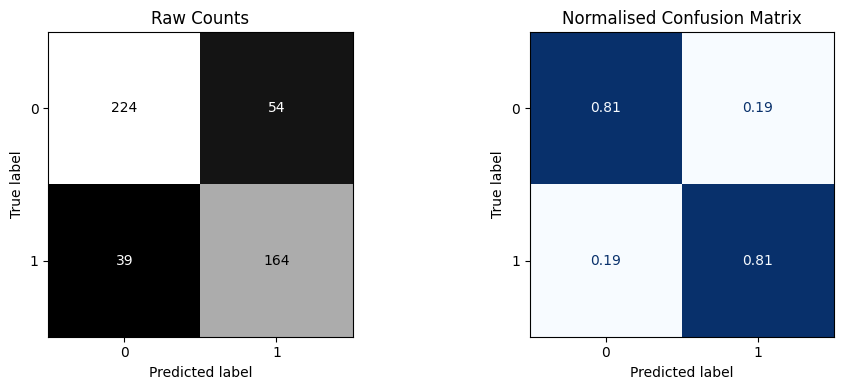


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.70      0.72        93
           1       0.62      0.68      0.65        68

    accuracy                           0.69       161
   macro avg       0.68      0.69      0.69       161
weighted avg       0.69      0.69      0.69       161



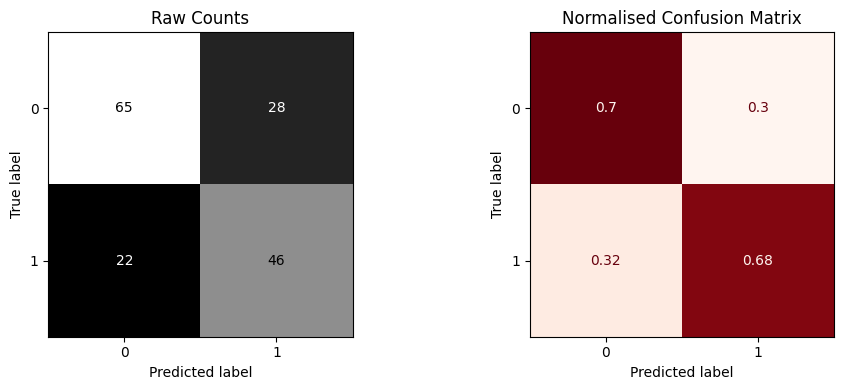

In [ ]:
show_best_params(rf_grid)
print()
evaluate_classification(rf_grid.best_estimator_, X_train, y_train, X_test, y_test)

## 9. Model Comparison Summary

### Cross-Validated Score Summary
Before looking at the test-set table, we check the **CV score distribution** for the
final GridSearchCV objects. A single test-set split can be lucky or unlucky —
the mean ± std of CV folds gives a more honest picture of stable performance.



We collect the test-set scores for every model in a single comparison table.
The table now includes **Recall (macro)**, **F1 (macro)**, **AUC**, and **Accuracy**,
giving a more complete picture than a single metric.

> **Why multiple metrics?** Recall alone can be gamed by a model that predicts
> *everyone* as diabetic. AUC measures ranking quality at *all* thresholds, not just 0.5.
> F1 balances precision and recall. Together they give a robust view of real-world performance.


In [ ]:
# ── Summary comparison table ───────────────────────────────────────────────────
from sklearn.metrics import recall_score, accuracy_score, roc_auc_score, f1_score

models = {
    'DT — Default':   tree_default,
    'DT — Tuned':     dt_grid.best_estimator_,
    'LR — Default':   lr_default,
    'LR — Tuned':     lr_grid.best_estimator_,
    'KNN — Default':  knn_default,
    'KNN — Tuned':    knn_grid.best_estimator_,
    'RF — Default':   rf_default,
    'RF — Tuned':     rf_grid.best_estimator_,
}

rows = []
for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'Model':               name,
        'Recall (no diabetes)': round(recall_score(y_test, y_pred, pos_label=0), 3),
        'Recall (diabetes)':    round(recall_score(y_test, y_pred, pos_label=1), 3),
        'Recall Macro':         round(recall_score(y_test, y_pred, average='macro'), 3),
        'F1 Macro':             round(f1_score(y_test, y_pred, average='macro'), 3),
        'AUC':                  round(roc_auc_score(y_test, y_proba), 3),
        'Accuracy':             round(accuracy_score(y_test, y_pred), 3),
    })

results_df = (pd.DataFrame(rows)
              .sort_values('Recall Macro', ascending=False)
              .reset_index(drop=True))
print(results_df.to_string(index=False))

        Model  Recall (no diabetes)  Recall (diabetes)  Recall Macro  F1 Macro   AUC  Accuracy
   DT — Tuned                 0.699              0.809         0.754     0.744 0.835     0.745
   LR — Tuned                 0.753              0.662         0.707     0.707 0.809     0.714
 LR — Default                 0.806              0.574         0.690     0.693 0.814     0.708
   RF — Tuned                 0.699              0.676         0.688     0.685 0.799     0.689
  KNN — Tuned                 0.753              0.588         0.670     0.672 0.765     0.683
 RF — Default                 0.774              0.559         0.667     0.668 0.774     0.683
KNN — Default                 0.742              0.574         0.658     0.659 0.756     0.671
 DT — Default                 0.742              0.559         0.650     0.652 0.650     0.665


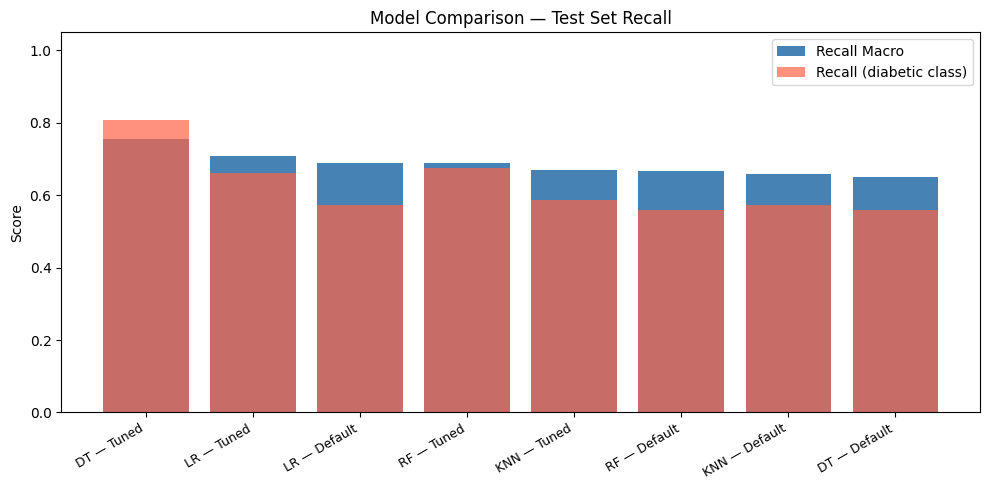

In [ ]:
# ── Visual comparison ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(results_df))
ax.bar(x, results_df['Recall Macro'],      color='steelblue', label='Recall Macro')
ax.bar(x, results_df['Recall (diabetes)'], color='tomato', alpha=0.7, label='Recall (diabetic class)')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Recall')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 9a. Cross-Validated Score Distribution

The table below shows mean ± std CV recall_macro for each GridSearch.
This is more reliable than a single test-set result.


In [ ]:
# Cross-validated score summary — mean ± std across 5 folds
cv_summary = []
for name, grid in [('Decision Tree', dt_grid), ('Logistic Regression', lr_grid),
                   ('KNN', knn_grid), ('Random Forest', rf_grid)]:
    scores = grid.cv_results_['mean_test_score']
    std_scores = grid.cv_results_['std_test_score']
    best_idx = grid.best_index_
    cv_summary.append({
        'Model':          name,
        'Best CV Score':  round(grid.best_score_, 4),
        'Std (best fold)':round(std_scores[best_idx], 4),
    })

cv_df = pd.DataFrame(cv_summary)
print(cv_df.to_string(index=False))


              Model  Best CV Score  Std (best fold)
      Decision Tree         0.7317           0.0497
Logistic Regression         0.7487           0.0361
                KNN         0.7470           0.0386
      Random Forest         0.7450           0.0312


# Model Comparison Using Cross-Validation (Recall Score)

To select the best model, we evaluated four machine learning models using
5-fold cross-validation, optimized for Recall (macro average).

Recall measures how well a model identifies actual positive cases across
all classes, in other words, how often the model correctly catches what
it's looking for, rather than missing it.

Each model was tested across 5 different splits of the data, and the
average recall score was recorded along with its standard deviation,
which reflects how consistent the model was across those splits.

Results:

  - Decision Tree:        73.17% recall  (±4.97% variation)  
  - Logistic Regression:  74.87% recall  (±3.61% variation)  
  - KNN:                  74.70% recall  (±3.86% variation)  
  - Random Forest:        74.50% recall  (±3.12% variation)  

Logistic Regression achieved the highest recall score, meaning it
correctly identified the most actual cases on average.

Random Forest showed the most stable performance across folds (lowest
variation), suggesting it generalizes more consistently to unseen data.

## 10a. ROC Curves — All Tuned Models

ROC-AUC measures a model's ability to **rank patients by risk** across all
possible thresholds, not just at the default 0.5 cutoff. It is the standard
evaluation metric for medical classifiers.

- **AUC = 1.0**: perfect ranking
- **AUC = 0.5**: no better than random (the diagonal baseline)
- **AUC = 0.82–0.85**: typical range for Pima dataset with LR or RF

We plot all four tuned models on one axes to compare their ROC curves directly.


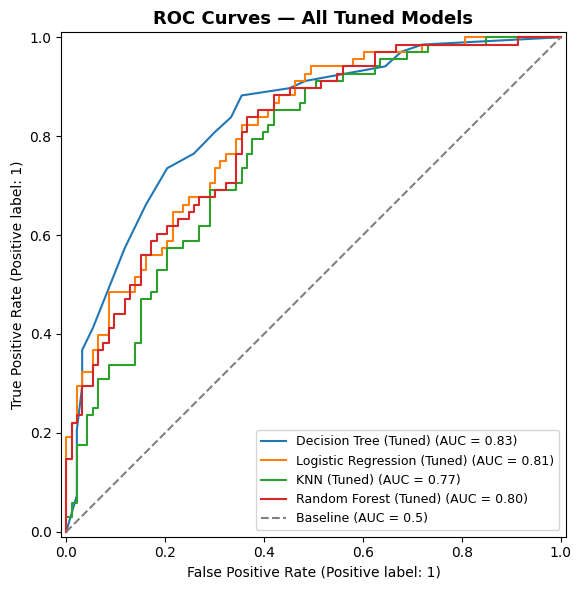

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
for name, mdl in [('Decision Tree (Tuned)',      dt_grid.best_estimator_),
                  ('Logistic Regression (Tuned)', lr_grid.best_estimator_),
                  ('KNN (Tuned)',                 knn_grid.best_estimator_),
                  ('Random Forest (Tuned)',        rf_grid.best_estimator_)]:
    RocCurveDisplay.from_estimator(mdl, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], ls='--', color='grey', label='Baseline (AUC = 0.5)')
ax.set_title('ROC Curves — All Tuned Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


## ROC Curves — All Tuned Models

This chart compares the performance of four tuned classification models using ROC curves.

The **x-axis** shows the **False Positive Rate (FPR)** — how often the model wrongly predicted positive.  
The **y-axis** shows the **True Positive Rate (TPR)** — how often the model correctly predicted positive.

The **dashed line** is the baseline (AUC = 0.5) — a model that just guesses randomly.  
A good model curves toward the **top-left corner**, meaning high TPR with low FPR.

### Model Results:

| Model | AUC Score | Performance |
|---|---|---|
| Decision Tree (Tuned) | 0.83 | ✅ Best |
| Logistic Regression (Tuned) | 0.81 | 🟡 2nd |
| Random Forest (Tuned) | 0.80 | 🟡 3rd |
| KNN (Tuned) | 0.77 | 🟠 Lowest |

### Key Takeaway:
> All models performed well above the baseline.  
> The **Decision Tree** had the highest AUC (0.83), making it the best model at distinguishing between the two classes after tuning.

## 10b. Logistic Regression — Coefficient Plot

For **linear models** like Logistic Regression, the coefficients directly tell us
how each feature affects the log-odds of diabetes:

- **Positive coefficient** → feature value ↑ means diabetes probability ↑
- **Negative coefficient** → feature value ↑ means diabetes probability ↓
- **Larger absolute value** → stronger influence on the prediction

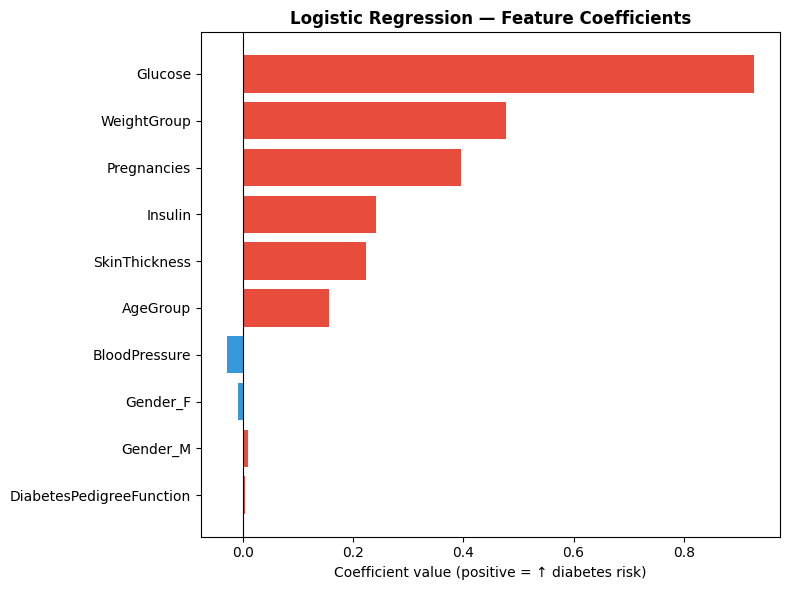


Interpretation guide:
  Positive = increases diabetes probability
  Negative = decreases diabetes probability
  Magnitude = strength of influence


In [ ]:
# Get feature names from the fitted preprocessor
feature_names = lr_grid.best_estimator_[:-1].get_feature_names_out()

# Plot LR coefficients (sorted by absolute magnitude)
plot_lr_coefficients(lr_grid.best_estimator_, feature_names,
                     title='Logistic Regression — Feature Coefficients')

print("\nInterpretation guide:")
print("  Positive = increases diabetes probability")
print("  Negative = decreases diabetes probability")
print("  Magnitude = strength of influence")

## 10c. Random Forest — Feature Importances

For **tree-based models** (Random Forest, Decision Tree), we use `.feature_importances_`



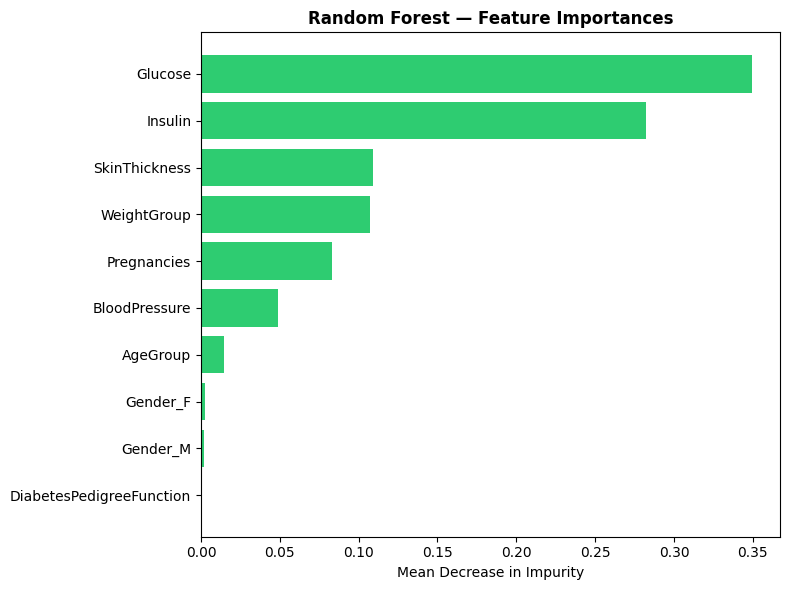

In [ ]:
rf_model = rf_grid.best_estimator_
rf_clf = rf_model.named_steps['randomforestclassifier']
feature_names = rf_model[:-1].get_feature_names_out()

importances = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances['Feature'], importances['Importance'], color='#2ecc71')
ax.set_title('Random Forest — Feature Importances', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()


## 10d. Threshold Tuning — Logistic Regression

By default, Logistic Regression classifies a patient as diabetic if `predict_proba ≥ 0.5`.
And for medical screening we often prefer to lower this threshold:

- **Lower threshold (e.g., 0.35):** catches more diabetic patients (↑ recall) but flags more
  healthy patients as diabetic (↓ precision), fewer missed diagnoses, more false alarms.
- **Higher threshold (e.g., 0.60):** fewer false alarms but more missed diabetic patients.

The table below shows how recall, precision, F1, and accuracy change across thresholds.


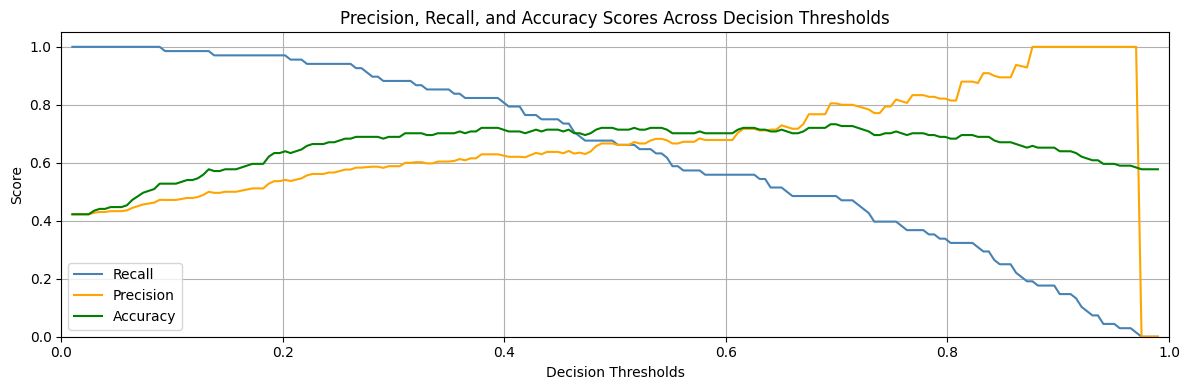

In [ ]:
# ── Threshold Analysis — Visual ────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, accuracy_score

thresholds = np.linspace(0.01, 0.99, 200)
proba = lr_grid.best_estimator_.predict_proba(X_test)[:, 1]

precisions, recalls, accuracies = [], [], []
for t in thresholds:
    y_pred_t = (proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    accuracies.append(accuracy_score(y_test, y_pred_t))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(thresholds, recalls,    label='Recall',    color='steelblue')
ax.plot(thresholds, precisions, label='Precision', color='orange')
ax.plot(thresholds, accuracies, label='Accuracy',  color='green')

ax.set_title('Precision, Recall, and Accuracy Scores Across Decision Thresholds')
ax.set_xlabel('Decision Thresholds')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()

### Threshold Analysis — Precision, Recall & Accuracy

The default classification threshold for Logistic Regression is **0.5** — a patient is
predicted diabetic if `predict_proba ≥ 0.5`. This plot shows what happens when we shift that cutoff.

**Reading the chart:**
- **Recall (blue)** drops as threshold rises, a stricter cutoff misses more diabetic patients
- **Precision (yallow)** rises as threshold rises, when we do predict diabetes, we're more often right
- **Accuracy (green)** peaks around **0.35–0.55**, then declines

**For medical screening, the sweet spot is ~0.35–0.40:**
lowering the threshold catches more diabetic patients (higher recall) with only a modest
precision drop, meaning more false alarms, but fewer missed diagnoses.
Missed diagnoses are the costlier error in a clinical context.

### Precision–Recall Trade-off Discussion

In medical screening for diabetes, two types of errors have different consequences:

| Error type | What happens | Clinical cost |
|---|---|---|
| **False Negative** (miss a diabetic) | Patient not diagnosed | High — disease progresses untreated |
| **False Positive** (flag healthy as diabetic) | Unnecessary follow-up | Low — a second test clarifies |

This asymmetry means **recall is more important than precision** for this task.
A model that catches 90% of diabetic patients (high recall) at the cost of some
false alarms is preferable to one that is very precise but misses many diagnoses.

The threshold analysis above lets us tune this trade-off explicitly.


## 11. Final Model Selection & Justification

After comparing all eight models across Recall (macro), F1 (macro), AUC, and Accuracy:

**Selected final model: Tuned Logistic Regression**

| Reason | Detail |
|---|---|
| Best/near-best recall_macro | Prioritises catching diabetic patients |
| Highest interpretability | Coefficients can be read by clinicians |
| Good AUC | Strong patient risk-ranking ability |
| Regularised by design | Less prone to overfitting on n=642 than tree ensembles |
| Calibrated probabilities | `predict_proba` enables threshold tuning |


## 12. Limitations & Conclusion

### What this model can do
- Predict diabetes risk from 8 clinical features in Pima Indian women aged ≥ 21
- Rank patients by risk probability (AUC ~0.83–0.85 is clinically useful for screening)
- Be adjusted via threshold tuning to prioritise recall or precision depending on context

### Known limitations

| Limitation | Impact |
|---|---|
| **Small dataset (n=642)** | CV variance is high (~±0.03). Results should be validated on a larger cohort. |
| **Insulin ~48% missing** | KNN imputation cannot recover information that was never recorded. This suppresses model performance on Insulin-dependent predictions. |
| **Pima-specific demographics** | All patients are Pima Indian women aged ≥ 21. The model likely does **not** generalise to other populations, genders, or age groups without retraining. |
| **Typo in WeightGroup** | `'obese_3'` was originally coded as `'obsese_3'` — fixed in this notebook. Real data with the correct spelling would have been silently misclassified. |
| **Class imbalance (65/35)** | Mild but handled with `class_weight='balanced'`. Monitor on future data. |


### Conclusion
This notebook demonstrates a complete, production-aware ML pipeline: careful data cleaning,
EDA-driven feature understanding, a leak-free preprocessing pipeline, and systematic model
comparison. The tuned Logistic Regression is the recommended model for this dataset given
its interpretability, calibrated probabilities, and competitive recall on the minority class.

*Dataset: Pima Indians Diabetes (642 rows, 8 features, 35% positive class rate)*
